# Data Preparation

In [4]:
# persiapkan library yang dibutuhkan
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Load dataset
df = pd.read_csv("/content/sample_data/House Price Prediction Dataset.csv")
# 5 baris pertama untuk melihat struktur data
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [6]:
# melihat jumlah dataset
df.shape

(2000, 10)

In [7]:
# melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [8]:
# Cek missing value seluruh variabel
missing_val = df.isnull().sum()
print(missing_val)

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [9]:
# Cek missing value yang tersembunyi, contoh: "Unknown", "NA"
df.isin(["Unknown", "NA", "N/A", "?", "None"]).sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [10]:
# Mengecek data duplikasi
df.duplicated().sum()

np.int64(0)

In [11]:
# Memahami distribusi statistik data numerik
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [12]:
# Memahami distribusi statistik data kategorik
df.describe(include='object')

,Location,Condition,Garage
count,2000,2000,2000
unique,4,4,2
top,Downtown,Fair,No
freq,558,521,1038


In [13]:
# Cek outlier dengan IQR (Interquartile Range)
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(len(outliers))

0


In [14]:
# eksplorasi value di setiap kolom kategorikal
# kolom Condition
df['Condition'].value_counts()

,count
Condition,
Fair,521
Excellent,511
Poor,507
Good,461


In [15]:
# eksplorasi value di setiap kolom kategorikal
# kolom Location
df['Location'].value_counts()

,count
Location,
Downtown,558
Urban,485
Suburban,483
Rural,474


In [16]:
# eksplorasi value di setiap kolom kategorikal
# kolom Garage
df['Garage'].value_counts()

,count
Garage,
No,1038
Yes,962


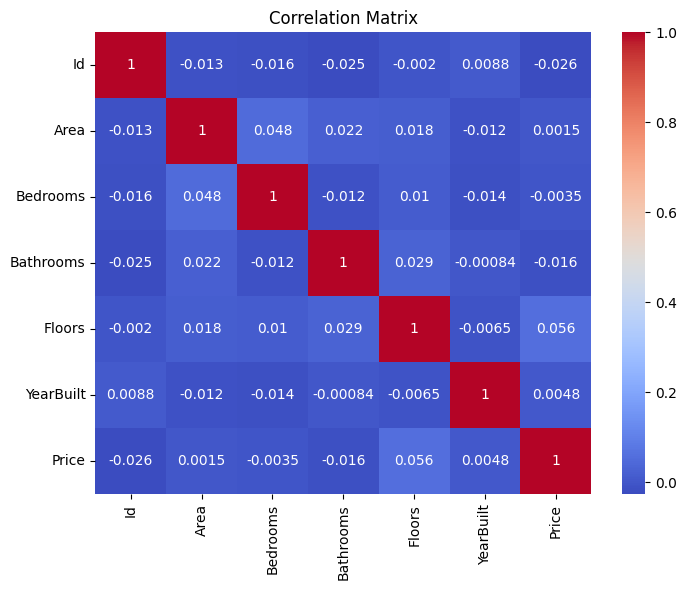

In [17]:
# Cek korelasi antar kolom/variabel numerik menggunakan heatmap
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [18]:
# hapus fitur yang tidak relevan
df = df.drop(['Id'], axis=1)

# EDA (Eksplorasi Data Analysis)

<Axes: xlabel='Price', ylabel='Count'>

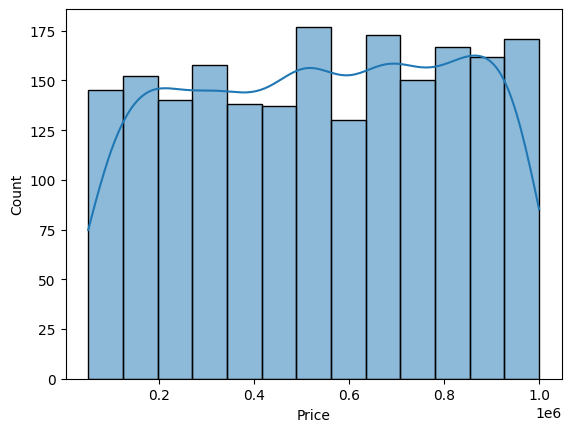

In [19]:
# Cek distribusi fitur target
sns.histplot(df['Price'], kde=True)

array([[<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'Bedrooms'}>],
       [<Axes: title={'center': 'Bathrooms'}>,
        <Axes: title={'center': 'Floors'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'Price'}>]], dtype=object)

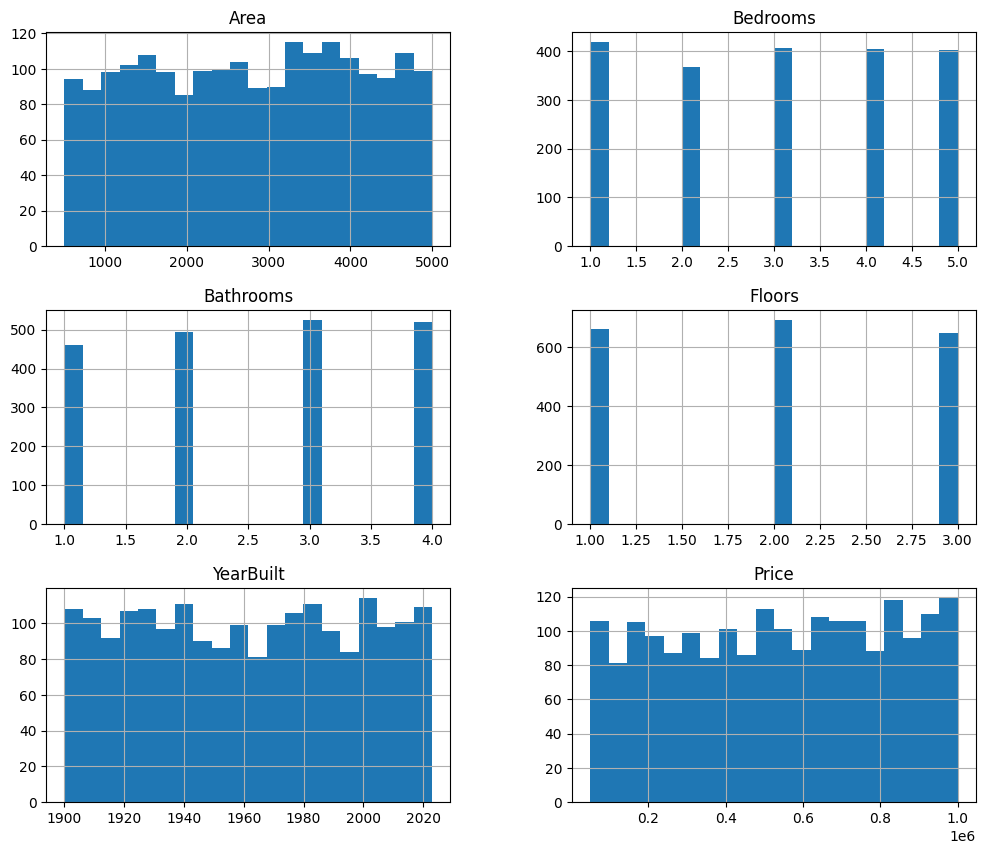

In [20]:
# Cek distribusi semua fitur
df.hist(figsize=(12,10), bins=20)

<Axes: xlabel='Location', ylabel='Price'>

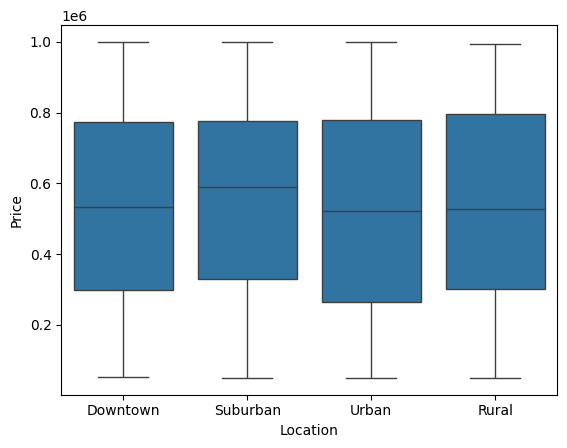

In [21]:
# cek distribusi harga per lokasi
sns.boxplot(x='Location', y='Price', data=df)

<Axes: xlabel='Condition', ylabel='Price'>

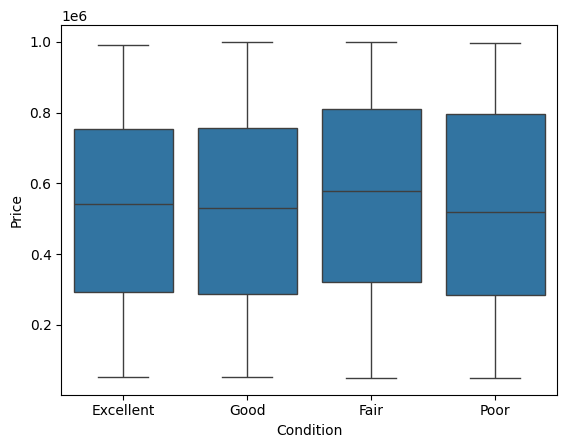

In [22]:
# cek distribusi harga per Kondisi
sns.boxplot(x='Condition', y='Price', data=df)

<Axes: xlabel='Area', ylabel='Price'>

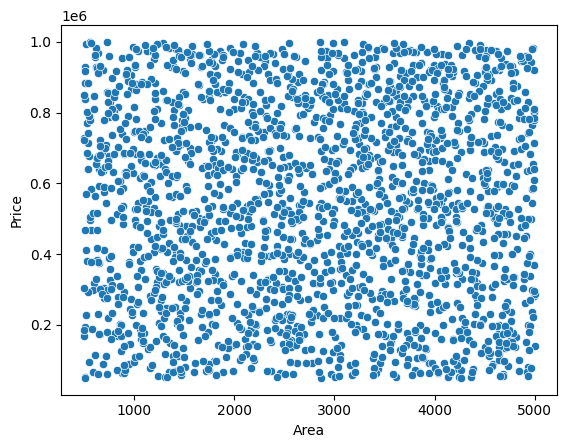

In [23]:
# cek distribusi harga per Area
sns.scatterplot(x='Area', y='Price', data=df)

# Data Preprocessing

## 1. Pembagian Data

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [25]:
# Melihat jumlah data setelah di bagi
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 8)
(400, 8)
(1600,)
(400,)


## 2. Encoding fitur kategorikal

In [26]:
# 1. Binary (Garage)
X_train['Garage'] = X_train['Garage'].map({'No': 0, 'Yes': 1})
X_test['Garage'] = X_test['Garage'].map({'No': 0, 'Yes': 1})

In [27]:
# 2. Ordinal/berurutan/tingkatan (Condition)
condition_mapping = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}
X_train['Condition'] = X_train['Condition'].map(condition_mapping)
X_test['Condition'] = X_test['Condition'].map(condition_mapping)

In [28]:
from sklearn.preprocessing import OneHotEncoder

# 3. Nominal (Location)
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

X_train_loc = encoder.fit_transform(X_train[['Location']])
X_test_loc = encoder.transform(X_test[['Location']])

# Ubah jadi DataFrame
loc_columns = encoder.get_feature_names_out(['Location'])

X_train_loc = pd.DataFrame(X_train_loc.toarray(), columns=loc_columns, index=X_train.index)
X_test_loc = pd.DataFrame(X_test_loc.toarray(), columns=loc_columns, index=X_test.index)

# Drop kolom lama + gabungkan
X_train = X_train.drop(columns=['Location'])
X_test = X_test.drop(columns=['Location'])

X_train = pd.concat([X_train, X_train_loc], axis=1)
X_test = pd.concat([X_test, X_test_loc], axis=1)

In [29]:
# Preview hasil akhir setelah di encoding
X_train.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Location_Rural,Location_Suburban,Location_Urban
968,4483,4,4,3,1933,3,0,0.0,0.0,1.0
240,1062,3,3,1,1970,2,0,0.0,0.0,0.0
819,1422,3,4,1,1993,2,1,0.0,0.0,1.0
692,2658,2,3,1,1972,0,1,1.0,0.0,0.0
420,3286,2,4,1,1981,3,1,1.0,0.0,0.0


In [30]:
# Cek hasil encoding spesifik
X_train['Garage'].value_counts()

,count
Garage,
0,841
1,759


In [31]:
# Cek hasil encoding spesifik
X_train['Condition'].value_counts()

,count
Condition,
1,423
0,410
3,400
2,367


In [32]:
X_train.filter(like='Location').head()

,Location_Rural,Location_Suburban,Location_Urban
968,0.0,0.0,1.0
240,0.0,0.0,0.0
819,0.0,0.0,1.0
692,1.0,0.0,0.0
420,1.0,0.0,0.0


## 3. Normalisasi / Scaling (Menyamakan skala fitur supaya tidak ada yang “mendominasi” model)
Apakah semua model butuh scaling? Tidak ✔️ Butuh scaling:

Linear Regression
Ridge / Lasso
KNN
SVM
❌ Tidak wajib:

Decision Tree
Random **Forest**

In [33]:
# pastikan semua fitur numerik
X_train.dtypes

,0
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Condition,int64
Garage,int64
Location_Rural,float64
Location_Suburban,float64
Location_Urban,float64


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [35]:
num_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
scaler = StandardScaler()

# FIT hanya di TRAIN
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# TRANSFORM di TEST
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Modeling

## Linear Regression

In [36]:
# Inisialisasi model LR
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [37]:
# Prediksi
y_pred = model.predict(X_test)

In [38]:
# Evaluasi Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 243453.00113858172
RMSE: 280057.76575275813
R2: -0.00814309997438234


In [39]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Floors,0.055890
YearBuilt,0.004845
Area,0.001542
Bedrooms,-0.003471
Bathrooms,-0.015737


In [40]:
# Cek struktur fitur
print(X_train.columns)
print(X_test.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition',
       'Garage', 'Location_Rural', 'Location_Suburban', 'Location_Urban'],
      dtype='object')
Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition',
       'Garage', 'Location_Rural', 'Location_Suburban', 'Location_Urban'],
      dtype='object')


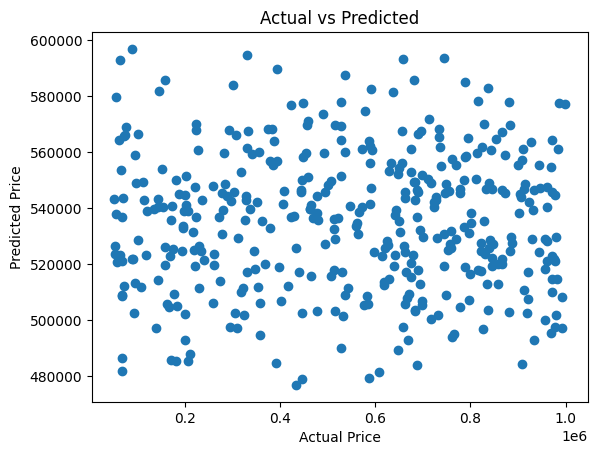

In [41]:
# Membandingkan Prediksi dan aktual

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [42]:
# Cek Cek overfitting
y_train_pred = model.predict(X_train)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_pred))

Train R2: 0.007937984359026595
Test R2: -0.00814309997438234


## RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print("RF R2:", rf.score(X_test, y_test))

Hasil eksperimen menunjukkan bahwa baik model linear (Linear regression) maupun non-linear (Random Forest) gagal mencapai performa yang memadai, yang mengindikasikan bahwa tidak adanya pola yang dapat dipelajari dalam data.